In [1]:
# ── paste this as a brand new first cell, before everything else ─────────────
import torch
print(f"GPU allocated at kernel start: {torch.cuda.memory_allocated(0)/1e9:.3f} GB")
print(f"GPU free at kernel start: {torch.cuda.mem_get_info(0)[0]/1e9:.1f} GB")

GPU allocated at kernel start: 0.000 GB
GPU free at kernel start: 15.5 GB


In [2]:
# ── CELL 00a: Nuclear GPU reset — MUST be first cell in Notebook 2 ──────────
# Clears any GPU memory held from previous notebooks in this Kaggle session.
# Run this ONCE before running any other cell.

import gc, torch

# kill any existing CUDA context completely
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        with torch.cuda.device(i):
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

# force Python garbage collection
gc.collect()

# verify
for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1e9
    free      = torch.cuda.mem_get_info(i)[0] / 1e9
    print(f"GPU {i}: allocated={allocated:.2f}GB  free={free:.1f}GB")

print("\nIf 'allocated' is still high after this cell, do a FULL KERNEL RESTART.")

GPU 0: allocated=0.00GB  free=15.5GB
GPU 1: allocated=0.00GB  free=15.5GB

If 'allocated' is still high after this cell, do a FULL KERNEL RESTART.


In [3]:
# ── CELL 00 REPLACEMENT: load everything from JSON only, skip pkl ─────────────
# csv_index.pkl was saved with CUDA tensor references that silently consume
# 5GB GPU memory on load. Rebuild csv_index from the JSON data instead.

import json, numpy as np, os

OUTPUTS_DIR = "/kaggle/input/datasets/vijayadurgaadithya/fixationformer-outputs"
DATA_ROOT   = "/kaggle/input/datasets/vijayadurgaadithya/mimic-gaze-jpg/mimic_part_jpg"
LABEL_NAMES = ["CHF", "Normal", "pneumonia"]
LABEL_MAP   = {"CHF": 0, "Normal": 1, "pneumonia": 2}

# load classification results
with open(f"{OUTPUTS_DIR}/test_results.json") as f:
    test_results = json.load(f)

# load attention weights
with open(f"{OUTPUTS_DIR}/attention_weights.json") as f:
    attention_data_raw = json.load(f)

attention_data = {
    k: {
        "fix":       np.array(v["fix"],       dtype=np.float32),
        "weights":   np.array(v["weights"],   dtype=np.float32),
        "top_k_idx": np.array(v["top_k_idx"], dtype=np.int64),
    }
    for k, v in attention_data_raw.items()
}

# ── rebuild csv_index from attention_data (same data, guaranteed CPU numpy) ──
# csv_index maps dicom_id -> fix array — exactly what attention_data["fix"] is
csv_index = {
    dicom_id: att["fix"]
    for dicom_id, att in attention_data.items()
}

# test_samples list for iteration
test_samples = [
    (v["image_path"].replace("mimic-part", "mimic-gaze-jpg"), v["true_label"])
    for v in test_results.values()
]

print(f"Loaded {len(test_results)} test results")
print(f"Loaded {len(attention_data)} attention weight sets")
print(f"Rebuilt csv_index: {len(csv_index)} entries (pure numpy, no GPU)")

# verify no GPU tensors
import torch
sample_val = next(iter(csv_index.values()))
print(f"csv_index value type : {type(sample_val)}")
print(f"csv_index value dtype: {sample_val.dtype}")
print(f"Is on GPU?           : {isinstance(sample_val, torch.Tensor) and sample_val.is_cuda}")
print(f"\nGPU allocated after Cell 00: {torch.cuda.memory_allocated(0)/1e9:.3f} GB")

Loaded 107 test results
Loaded 107 attention weight sets
Rebuilt csv_index: 107 entries (pure numpy, no GPU)
csv_index value type : <class 'numpy.ndarray'>
csv_index value dtype: float32
Is on GPU?           : False

GPU allocated after Cell 00: 0.000 GB


In [4]:
!pip install -q transformers accelerate bitsandbytes pillow

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB" if torch.cuda.is_available() else "")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inc

In [5]:
# ── DIAGNOSTIC: see exactly what's using GPU memory ─────────────────────────
import torch

print(f"Total GPU VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Currently allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Currently reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"Free               : {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

Total GPU VRAM    : 15.64 GB
Currently allocated: 0.00 GB
Currently reserved : 0.00 GB
Free               : 15.53 GB


In [6]:
import torch
DATA_ROOT = "/kaggle/input/datasets/vijayadurgaadithya/mimic-gaze-jpg/mimic_part_jpg"
DEVICE = torch.device("cuda:0")
LABEL_NAMES = ["CHF", "Normal", "pneumonia"]
LABEL_MAP   = {"CHF": 0, "Normal": 1, "pneumonia": 2}
print(f"DEVICE: {DEVICE}")

DEVICE: cuda:0


In [7]:
#Cell 5
import pandas as pd

csv_path = os.path.join(DATA_ROOT, "gaze", "fixations.csv")
df_raw = pd.read_csv(csv_path)

print("Shape     :", df_raw.shape)
print("Columns   :", list(df_raw.columns))
print("\nFirst 3 rows:")
print(df_raw.head(3).to_string())
print("\nPer-column stats:")
print(df_raw.describe(include="all").to_string())


Shape     : (48959, 37)
Columns   : ['SESSION_ID', 'MEDIA_ID', 'DICOM_ID', 'CNT', 'Time (in secs)', 'TIMETICK(f=10000000)', 'FPOGX', 'FPOGY', 'FPOGS', 'FPOGD', 'FPOGID', 'FPOGV', 'BPOGX', 'BPOGY', 'BPOGV', 'LPCX', 'LPCY', 'LPD', 'LPS', 'LPV', 'RPCX', 'RPCY', 'RPD', 'RPS', 'RPV', 'BKID', 'BKDUR', 'BKPMIN', 'LPMM', 'LPMMV', 'RPMM', 'RPMMV', 'SACCADE_MAG', 'SACCADE_DIR', 'VID_FRAME', 'X_ORIGINAL', 'Y_ORIGINAL']

First 3 rows:
   SESSION_ID  MEDIA_ID                                      DICOM_ID  CNT  Time (in secs)  TIMETICK(f=10000000)    FPOGX    FPOGY    FPOGS    FPOGD  FPOGID  FPOGV    BPOGX    BPOGY  BPOGV     LPCX     LPCY       LPD      LPS  LPV     RPCX     RPCY       RPD      RPS  RPV  BKID  BKDUR  BKPMIN     LPMM  LPMMV     RPMM  RPMMV  SACCADE_MAG  SACCADE_DIR  VID_FRAME  X_ORIGINAL  Y_ORIGINAL
0           1         0  1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b   45         0.72363          6.962164e+11  0.45224  0.33879  0.01794  0.70569       2      1  0.46134  0.26619     

In [8]:
# ── Run this BEFORE Cell 05 to find what's consuming 14GB ───────────────────
import torch, gc

print("Memory snapshot before each import:\n")

before = torch.cuda.memory_allocated(0) / 1e9
print(f"Start: {before:.3f} GB allocated on GPU 0")

Memory snapshot before each import:

Start: 0.000 GB allocated on GPU 0


In [9]:
# ── MEMORY PROBE — run this as a new cell between each existing cell ─────────
import torch

def mem_check(label):
    alloc = torch.cuda.memory_allocated(0) / 1e9
    free  = torch.cuda.mem_get_info(0)[0] / 1e9
    print(f"{label:40s} | allocated={alloc:.3f}GB  free={free:.1f}GB")

mem_check("after Cell 00 (load json/pkl)")

after Cell 00 (load json/pkl)            | allocated=0.000GB  free=15.5GB


In [10]:
from transformers import LlavaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch

# LLaVA-Med CXR is too large to load with 4-bit quantization on a 15GB T4
# because bitsandbytes needs ~14GB peak RAM during the quantization step.
# Solution: use a smaller base model that fits within the peak allocation budget.

# Option A: LLaVA-1.5-7B with 8-bit (peak ~8GB, settled ~7GB — fits T4)
LLAVA_MODEL_ID = "llava-hf/llava-1.5-7b-hf"

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,              # 8-bit instead of 4-bit — smaller peak
    llm_int8_threshold=6.0,
)

print(f"Loading {LLAVA_MODEL_ID} (8-bit)...")
llava_processor = AutoProcessor.from_pretrained(LLAVA_MODEL_ID)
llava_model = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": "cuda:0"},
    low_cpu_mem_usage=True,
    max_memory={0: "10GiB", "cpu": "20GiB"},
)
llava_model.eval()
DEVICE = torch.device("cuda:0")

print(f"Model loaded.")
print(f"GPU 0 used : {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print(f"GPU 0 free : {torch.cuda.mem_get_info(0)[0]/1e9:.1f} GB")

Loading llava-hf/llava-1.5-7b-hf (8-bit)...


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded.
GPU 0 used : 7.35 GB
GPU 0 free : 2.3 GB


In [11]:
# ── REPLACE Cell [06] entirely with this ─────────────────────────────────────
# Notebook 2 does NOT use FixationFormer — remove build_structured_description()
# which was accidentally copied from Notebook 1 and was loading 14GB to GPU.
# Only keep render_gaze_overlay() which is a pure matplotlib/PIL function.

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import io, os

def render_gaze_overlay(image_path, fix, top_k_idx=None, save_path=None):
    """
    Renders gaze overlay image — pure matplotlib/PIL, no model, no GPU.
    Used as fallback if pre-rendered overlay PNG is missing from disk.
    """
    pil_img = Image.open(image_path).convert("RGB")
    img_np  = np.array(pil_img.resize((224, 224)))

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img_np)
    ax.scatter(fix[:,0]*224, fix[:,1]*224, c=range(len(fix)), cmap="plasma",
               s=70, zorder=5, edgecolors="white", linewidths=0.5, alpha=0.85)
    ax.plot(fix[:,0]*224, fix[:,1]*224, "w--", alpha=0.4, linewidth=1)

    if top_k_idx is not None:
        top_x = [fix[i,0]*224 for i in top_k_idx]
        top_y = [fix[i,1]*224 for i in top_k_idx]
        ax.scatter(top_x, top_y, c="red", s=160, zorder=6,
                   edgecolors="yellow", linewidths=1.5, marker="*")

    ax.axis("off"); plt.tight_layout(pad=0)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=100, bbox_inches="tight", pad_inches=0)
    plt.close(fig); buf.seek(0)
    overlay_img = Image.open(buf).convert("RGB")
    if save_path:
        overlay_img.save(save_path)
    return overlay_img


print("render_gaze_overlay() defined — no model, no GPU memory used.")

render_gaze_overlay() defined — no model, no GPU memory used.


In [12]:
import pandas as pd

df_full = pd.read_csv(os.path.join(DATA_ROOT, "gaze", "fixations.csv"))
print(f"Loaded full CSV: {df_full.shape}")

Loaded full CSV: (48959, 37)


In [13]:
class AttentionCapture:
    """Wraps the model's Two-Way attention to capture weights during forward."""
    def __init__(self, model):
        self.model = model
        self.captured = {}
        self._originals = {}   # store original forward methods so we can restore them
        self._register()

    def _register(self):
        base = self.model.module if hasattr(self.model, "module") else self.model
        integration = base.integration

        for layer_idx, layer in enumerate(integration.layers):
            # ── restore first, in case this layer was already wrapped ────────
            if layer_idx in self._originals:
                continue   # already registered on this instance, skip

            orig_img2gaze = layer.img2gaze.forward
            orig_gaze2img = layer.gaze2img.forward
            self._originals[layer_idx] = (orig_img2gaze, orig_gaze2img)

            def make_img2gaze_hook(idx, orig):
                def hooked_forward(query, key, value, **kwargs):
                    kwargs.pop("need_weights", None)            # avoid duplicate kwarg
                    kwargs.pop("average_attn_weights", None)
                    out, weights = orig(query, key, value,
                                        need_weights=True, average_attn_weights=False, **kwargs)
                    self.captured.setdefault(idx, {})["img2gaze"] = weights.detach().cpu()
                    return out, weights
                return hooked_forward

            def make_gaze2img_hook(idx, orig):
                def hooked_forward(query, key, value, **kwargs):
                    kwargs.pop("need_weights", None)
                    kwargs.pop("average_attn_weights", None)
                    out, weights = orig(query, key, value,
                                        need_weights=True, average_attn_weights=False, **kwargs)
                    self.captured.setdefault(idx, {})["gaze2img"] = weights.detach().cpu()
                    return out, weights
                return hooked_forward

            layer.img2gaze.forward = make_img2gaze_hook(layer_idx, orig_img2gaze)
            layer.gaze2img.forward = make_gaze2img_hook(layer_idx, orig_gaze2img)

    def restore(self):
        """Unwraps the hooks, returning the model's attention layers to their original state."""
        base = self.model.module if hasattr(self.model, "module") else self.model
        integration = base.integration
        for layer_idx, layer in enumerate(integration.layers):
            if layer_idx in self._originals:
                orig_img2gaze, orig_gaze2img = self._originals[layer_idx]
                layer.img2gaze.forward = orig_img2gaze
                layer.gaze2img.forward = orig_gaze2img
        self._originals = {}

    def clear(self):
        self.captured = {}


print("AttentionCapture (fixed, restorable) defined.")

AttentionCapture (fixed, restorable) defined.


In [14]:
def get_anatomical_zone(x, y):
    """
    Maps normalised (x,y) in [0,1] to a named chest X-ray region.
    Based on standard PA chest X-ray anatomy landmarks.
    """
    if y < 0.30:
        v_zone = "apex"
    elif y < 0.55:
        v_zone = "upper"
    elif y < 0.75:
        v_zone = "middle"
    else:
        v_zone = "base"

    if x < 0.35:
        h_zone = "left"
    elif x < 0.65:
        h_zone = "central"
    else:
        h_zone = "right"

    zone_map = {
        ("left",    "apex"):   "Left Apex",
        ("central", "apex"):   "Trachea / Carina",
        ("right",   "apex"):   "Right Apex",
        ("left",    "upper"):  "Left Upper Lobe",
        ("central", "upper"):  "Upper Mediastinum",
        ("right",   "upper"):  "Right Upper Lobe",
        ("left",    "middle"): "Left Cardiac Border",
        ("central", "middle"): "Cardiac Silhouette",
        ("right",   "middle"): "Right Cardiac Border",
        ("left",    "base"):   "Left Costophrenic Angle",
        ("central", "base"):   "Lower Mediastinum",
        ("right",   "base"):   "Right Costophrenic Angle",
    }
    return zone_map.get((h_zone, v_zone), f"{h_zone} {v_zone}")


print("get_anatomical_zone defined.")

get_anatomical_zone defined.


In [15]:
def analyse_saccade_pattern(fix):
    """
    Classifies the radiologist's reading strategy directly from the SAME
    fixation array the model actually processed — no dependency on raw CSV.

    Args:
        fix: (N, 4) numpy array — [x, y, t, d], all normalised [0,1]
             this is the exact array passed into the GazeTokenizer

    Returns:
        str — pipe-separated pattern description
    """
    if fix is None or len(fix) < 3:
        return "insufficient fixations for pattern analysis"

    xs   = fix[:, 0]
    ys   = fix[:, 1]
    ts   = fix[:, 2]
    durs = fix[:, 3]

    patterns = []

    # bilateral: fixations span both left (<0.40) and right (>0.60) sides
    if xs.min() < 0.40 and xs.max() > 0.60:
        patterns.append("bilateral scanning (left ↔ right)")

    # focal: low spatial variance = dwelling in one area
    if xs.std() < 0.12 and ys.std() < 0.12:
        patterns.append("focal dwelling (concentrated fixations)")

    # prolonged dwell: high average duration
    if durs.mean() > 0.30:
        patterns.append("prolonged fixation durations (high cognitive load)")

    # saccade magnitude approximated from consecutive fixation distances
    # (replaces dependency on raw SACCADE_MAG column)
    if len(fix) > 1:
        dx = np.diff(xs)
        dy = np.diff(ys)
        step_dist = np.sqrt(dx**2 + dy**2)   # normalised distance per step
        if step_dist.mean() > 0.18:
            patterns.append("large saccades (wide area scanning)")

    # top-to-bottom sweep: second half of sequence is lower than first half
    if len(ys) > 3:
        first_half_y  = ys[: len(ys)//2].mean()
        second_half_y = ys[len(ys)//2 :].mean()
        if second_half_y - first_half_y > 0.15:
            patterns.append("top-to-bottom sweep")
        elif first_half_y - second_half_y > 0.15:
            patterns.append("bottom-to-top sweep")

    return " | ".join(patterns) if patterns else "mixed scanning pattern"


print("analyse_saccade_pattern() updated — now reads directly from fix array.")

analyse_saccade_pattern() updated — now reads directly from fix array.


In [16]:
def compute_gaze_geometry(fix, top_k_idx=None, img_size=224):
    """
    Computes geometry for BOTH the complete fixation trajectory AND the
    top-K most attended fixations separately — they answer different
    questions and both matter for the report.

    Args:
        fix:        (N, 4) full fixation array
        top_k_idx:  indices of top-attended fixations (optional)
        img_size:   pixel dimension of the square image

    Returns:
        dict with "all" and "top_k" geometry sub-dicts
    """
    def _geometry_for(points):
        x_min, x_max = points[:, 0].min(), points[:, 0].max()
        y_min, y_max = points[:, 1].min(), points[:, 1].max()
        cx, cy = points[:, 0].mean(), points[:, 1].mean()
        width, height = x_max - x_min, y_max - y_min
        area = width * height

        if area < 0.03:
            spread_desc = "a tight, focal cluster"
        elif area < 0.10:
            spread_desc = "a moderately concentrated area"
        else:
            spread_desc = "a widely scattered area"

        if x_max < 0.40:
            h_desc = "left side"
        elif x_min > 0.60:
            h_desc = "right side"
        elif width > 0.35:
            h_desc = "spanning left and right (bilateral)"
        else:
            h_desc = "central/midline"

        if y_max < 0.35:
            v_desc = "upper zone"
        elif y_min > 0.65:
            v_desc = "lower zone"
        elif height > 0.35:
            v_desc = "spanning upper and lower zones"
        else:
            v_desc = "mid zone"

        return {
            "pixel_points":  [(round(x*img_size), round(y*img_size)) for x, y in points],
            "pixel_centroid": (round(cx*img_size), round(cy*img_size)),
            "pixel_bbox":     (round(x_min*img_size), round(y_min*img_size),
                               round(x_max*img_size), round(y_max*img_size)),
            "width_norm":  round(float(width), 3),
            "height_norm": round(float(height), 3),
            "horizontal_desc": h_desc,
            "vertical_desc":   v_desc,
            "spread_desc":     spread_desc,
        }

    all_points = fix[:, :2]
    result = {"all": _geometry_for(all_points)}

    if top_k_idx is not None and len(top_k_idx) > 0:
        top_points = fix[top_k_idx][:, :2]
        result["top_k"] = _geometry_for(top_points)
    else:
        result["top_k"] = None

    return result


print("compute_gaze_geometry() updated — computes full trajectory + top-K separately.")

compute_gaze_geometry() updated — computes full trajectory + top-K separately.


In [17]:
def build_complete_fixation_description(fix, importance_scores, geometry, img_size=224):
    """
    Builds the full text block the VLM receives — ALL fixation coordinates
    in temporal order, with importance scores, plus both geometry summaries
    (full trajectory + top-attended subset).

    This is what teaches the VLM to locate anatomy from coordinates: every
    single fixation is listed, not just the top 5, so the VLM can trace the
    complete reading pattern the way it would read a radiologist's eye log.
    """
    N = len(fix)
    norm_scores = importance_scores / (importance_scores.sum() + 1e-8)
    top5_idx = np.argsort(norm_scores)[::-1][:5]

    lines = []
    lines.append(f"COORDINATE SYSTEM: image is {img_size}×{img_size} pixels.")
    lines.append(f"x=0 is LEFT edge, x={img_size} is RIGHT edge.")
    lines.append(f"y=0 is TOP edge, y={img_size} is BOTTOM edge.")
    lines.append("")
    lines.append("PA CHEST X-RAY ANATOMY REFERENCE (use this to locate findings from coordinates):")
    lines.append(f"  - Trachea/mediastinum: roughly x={img_size*0.40:.0f}-{img_size*0.60:.0f}, y={img_size*0.05:.0f}-{img_size*0.45:.0f} (upper midline)")
    lines.append(f"  - Cardiac silhouette: roughly x={img_size*0.30:.0f}-{img_size*0.62:.0f}, y={img_size*0.50:.0f}-{img_size*0.78:.0f} (lower-mid, left-of-center)")
    lines.append(f"  - Left lung field: x < {img_size*0.45:.0f}, full height")
    lines.append(f"  - Right lung field: x > {img_size*0.55:.0f}, full height")
    lines.append(f"  - Costophrenic angles: lower corners, y > {img_size*0.78:.0f}")
    lines.append(f"  - Apices: y < {img_size*0.20:.0f}")
    lines.append("")
    lines.append(f"ALL {N} FIXATIONS, IN TEMPORAL ORDER (the radiologist's complete reading path):")
    lines.append("Format: [fix#] pixel(x,y) | importance_score | dwell_duration")
    lines.append("")

    for i in range(N):
        x_norm, y_norm, t_norm, d_norm = fix[i]
        px, py = round(float(x_norm)*img_size), round(float(y_norm)*img_size)
        imp = float(norm_scores[i])
        marker = " ★HIGH-ATTENTION" if i in top5_idx else ""
        lines.append(f"  [{i+1:02d}] pixel({px:3d},{py:3d}) | importance={imp:.3f} | dwell={d_norm:.2f}{marker}")

    lines.append("")
    lines.append("FULL TRAJECTORY GEOMETRY (how the radiologist scanned overall):")
    g_all = geometry["all"]
    lines.append(f"  Centroid: pixel{g_all['pixel_centroid']}")
    lines.append(f"  Bounding area: pixel{g_all['pixel_bbox']} (x_min,y_min,x_max,y_max)")
    lines.append(f"  Pattern: {g_all['spread_desc']}, {g_all['horizontal_desc']}, {g_all['vertical_desc']}")

    if geometry["top_k"] is not None:
        lines.append("")
        lines.append("HIGH-ATTENTION SUBSET GEOMETRY (where the AI's decision concentrated):")
        g_top = geometry["top_k"]
        lines.append(f"  Centroid: pixel{g_top['pixel_centroid']}")
        lines.append(f"  Bounding area: pixel{g_top['pixel_bbox']}")
        lines.append(f"  Pattern: {g_top['spread_desc']}, {g_top['horizontal_desc']}, {g_top['vertical_desc']}")

    return "\n".join(lines)


print("build_complete_fixation_description() defined — sends ALL fixations to the VLM.")

build_complete_fixation_description() defined — sends ALL fixations to the VLM.


In [18]:
def build_patient_context_text(patient_context=None):
    """
    Converts optional patient clinical context into text for the VLM prompt.
    This is what makes the system genuinely multimodal beyond image+gaze.

    Args:
        patient_context: dict, e.g.
            {
                "age": 68,
                "sex": "M",
                "symptoms": "shortness of breath, bilateral leg swelling",
                "history": "hypertension, prior MI 2019",
                "vitals": "SpO2 91%, HR 102, Temp 37.1C",
            }
            Pass None if no clinical context is available.

    Returns:
        str — formatted text block, or a note that no context was provided
    """
    if not patient_context:
        return "PATIENT CONTEXT: Not provided. Base the report on imaging and gaze findings only."

    lines = ["PATIENT CONTEXT:"]
    if "age" in patient_context or "sex" in patient_context:
        lines.append(f"  Age/Sex: {patient_context.get('age', 'unknown')} / {patient_context.get('sex', 'unknown')}")
    if "symptoms" in patient_context:
        lines.append(f"  Presenting symptoms: {patient_context['symptoms']}")
    if "history" in patient_context:
        lines.append(f"  Relevant history: {patient_context['history']}")
    if "vitals" in patient_context:
        lines.append(f"  Vitals/labs: {patient_context['vitals']}")

    return "\n".join(lines)


print("build_patient_context_text() defined.")

build_patient_context_text() defined.


In [19]:
# ── MEDICAL TERMINOLOGY MAP ───────────────────────────────────────────────────
# Maps (predicted class, anatomical region) → the specific clinical terms a
# radiologist would use, conditioned on gaze attention landing in that region.
# This is what the VLM draws from instead of describing gaze geometry directly.

MEDICAL_TERMINOLOGY = {
    "CHF": {
        "cardiac":       ["cardiomegaly", "enlarged cardiac silhouette",
                          "increased cardiothoracic ratio (>0.5)"],
        "perihilar":     ["perihilar haziness", "vascular congestion",
                          "indistinct hilar vessels", "cephalization"],
        "costophrenic":  ["blunting of the costophrenic angle",
                          "pleural effusion", "fluid in the costophrenic sulcus"],
        "lung_field":    ["interstitial edema", "Kerley B lines",
                          "bilateral airspace haziness"],
        "mediastinum":   ["widened mediastinum", "vascular pedicle widening"],
        "default":       ["findings consistent with volume overload"],
    },
    "pneumonia": {
        "lung_field":    ["focal consolidation", "airspace opacity",
                          "air bronchograms", "patchy infiltrate"],
        "perihilar":     ["perihilar consolidation", "peribronchial thickening"],
        "costophrenic":  ["blunting suggestive of parapneumonic effusion"],
        "apex":          ["apical opacity", "upper lobe consolidation"],
        "cardiac":       ["silhouette sign with adjacent consolidation"],
        "mediastinum":   ["no significant mediastinal widening"],
        "default":       ["focal airspace disease"],
    },
    "Normal": {
        "cardiac":       ["normal cardiac silhouette", "cardiothoracic ratio within normal limits"],
        "lung_field":    ["clear lung fields", "no focal consolidation"],
        "costophrenic":  ["costophrenic angles sharp and clear"],
        "perihilar":     ["normal hilar markings"],
        "mediastinum":   ["mediastinum within normal limits"],
        "apex":          ["apices clear"],
        "default":       ["no acute cardiopulmonary abnormality"],
    },
}


def coordinate_to_region(px, py, img_size=224):
    """
    Maps a pixel coordinate to a coarse anatomical region key used to look up
    MEDICAL_TERMINOLOGY. This is intentionally coarser than get_anatomical_zone
    (fewer categories) since it only needs to pick a terminology bucket, not
    give a precise zone label.
    """
    x_norm, y_norm = px / img_size, py / img_size

    if y_norm < 0.20:
        return "apex"
    if y_norm > 0.78:
        return "costophrenic"
    if 0.40 <= x_norm <= 0.60 and y_norm < 0.45:
        return "mediastinum"
    if 0.30 <= x_norm <= 0.62 and 0.45 <= y_norm <= 0.78:
        return "cardiac"
    if 0.35 <= x_norm <= 0.65 and 0.30 <= y_norm <= 0.55:
        return "perihilar"
    return "lung_field"


def build_terminology_guide(pred_label, fix, top_k_idx, img_size=224):
    """
    For the predicted class, determines which anatomical regions the
    high-attention fixations fall into, and returns the SPECIFIC medical
    terms the VLM should use for each region — not generic prose.

    Returns:
        str — formatted terminology guide for the prompt
    """
    term_map = MEDICAL_TERMINOLOGY.get(pred_label, MEDICAL_TERMINOLOGY["Normal"])

    region_hits = {}
    for idx in top_k_idx:
        px, py = round(float(fix[idx,0])*img_size), round(float(fix[idx,1])*img_size)
        region = coordinate_to_region(px, py, img_size)
        region_hits.setdefault(region, []).append((idx+1, px, py))

    lines = [f"MEDICAL TERMINOLOGY TO USE (for {pred_label} findings, by region attended):"]
    if not region_hits:
        lines.append(f"  {', '.join(term_map['default'])}")
    else:
        for region, fixations in region_hits.items():
            terms = term_map.get(region, term_map["default"])
            fix_refs = ", ".join(f"#{n}({x},{y})" for n,x,y in fixations)
            lines.append(f"  Region '{region}' (fixations {fix_refs}): use terms like {', '.join(terms)}")

    lines.append("")
    lines.append("You MUST use terminology from this list when describing findings in this region.")
    lines.append("Do not invent clinical terms not listed here or in standard radiology vocabulary.")

    return "\n".join(lines)


print("Medical terminology mapping defined.")

Medical terminology mapping defined.


In [20]:
def check_coordinate_validity(report_text, fix, img_size=224):
    """
    Scans the generated report for any pixel coordinate citations and verifies
    each one matches an ACTUAL fixation coordinate from the input data, within
    a small tolerance. Flags any fabricated/hallucinated coordinate.

    Args:
        report_text: the VLM's generated text (findings + impression)
        fix:         (N, 4) the real fixation array used as input
        img_size:    pixel dimension of the image

    Returns:
        dict with validity flags and any fabricated coordinates found
    """
    # build the set of all REAL pixel coordinates that exist in the input
    real_pixel_coords = set()
    for x, y, t, d in fix:
        px, py = round(float(x) * img_size), round(float(y) * img_size)
        real_pixel_coords.add((px, py))

    # extract every "pixel (x, y)" style citation from the generated text
    coord_pattern = r"\(?\s*(\d+)\s*,\s*(\d+)\s*\)?"
    # restrict to contexts that look like coordinate citations, not just any two numbers
    citation_pattern = r"(?:pixel|fixation\w*\s*#?\d*\D{0,15})\(?\s*(\d+)\s*,\s*(\d+)\s*\)"

    found_coords = re.findall(citation_pattern, report_text, flags=re.IGNORECASE)

    fabricated = []
    valid = []
    TOLERANCE = 15   # pixels — allow for rounding/description imprecision

    for x_str, y_str in found_coords:
        px, py = int(x_str), int(y_str)

        # immediate out-of-bounds check
        if px > img_size or py > img_size or px < 0 or py < 0:
            fabricated.append((px, py, "out of image bounds"))
            continue

        # check if any real coordinate is within tolerance
        is_real = any(
            abs(px - rx) <= TOLERANCE and abs(py - ry) <= TOLERANCE
            for rx, ry in real_pixel_coords
        )
        if is_real:
            valid.append((px, py))
        else:
            fabricated.append((px, py, "no matching fixation found"))

    return {
        "all_citations_valid": len(fabricated) == 0,
        "valid_coordinates": valid,
        "fabricated_coordinates": fabricated,
        "total_citations_found": len(found_coords),
    }


def print_coordinate_check(check_result):
    status = "✅ ALL VALID" if check_result["all_citations_valid"] else "⚠️  FABRICATED COORDINATES FOUND"
    print(f"\nCoordinate validity check: {status}")
    print(f"Total coordinate citations in report: {check_result['total_citations_found']}")
    if check_result["fabricated_coordinates"]:
        print("Fabricated coordinates detected:")
        for px, py, reason in check_result["fabricated_coordinates"]:
            print(f"  ({px},{py}) — {reason}")


print("check_coordinate_validity() defined.")

check_coordinate_validity() defined.


In [32]:
def build_clinical_intake_text(intake=None):
    if not intake:
        return "CLINICAL INTAKE: Not provided."

    lines = ["CLINICAL INTAKE (radiologist-provided, use ONLY this for correlation):"]
    lines.append("=" * 60)

    s = intake.get("symptoms", {})
    if s:
        lines.append("  SYMPTOMS:")
        if s.get("chief_complaint"): lines.append(f"    Chief complaint: {s['chief_complaint']}")
        if s.get("dyspnea_severity"): lines.append(f"    Dyspnea: {s['dyspnea_severity']}")
        if s.get("chest_pain"): lines.append(f"    Chest pain: {s['chest_pain']}")
        if s.get("cough"): lines.append(f"    Cough: {s['cough']}")
        if "fever" in s: lines.append(f"    Fever: {'present' if s['fever'] else 'absent'}")

    p = intake.get("physical_exam", {})
    if p:
        lines.append("  PHYSICAL EXAMINATION:")
        vitals = []
        if p.get("bp"): vitals.append(f"BP {p['bp']}")
        if p.get("hr"): vitals.append(f"HR {p['hr']}")
        if p.get("spo2"): vitals.append(f"SpO2 {p['spo2']}")
        if p.get("temp"): vitals.append(f"Temp {p['temp']}")
        if vitals: lines.append(f"    Vitals: {', '.join(vitals)}")
        if p.get("auscultation"): lines.append(f"    Auscultation: {p['auscultation']}")
        if p.get("edema"): lines.append(f"    Edema: {p['edema']}")

    h = intake.get("history", {})
    if h:
        lines.append("  HISTORY:")
        if h.get("cardiac"): lines.append(f"    Cardiac: {h['cardiac']}")
        if h.get("pulmonary"): lines.append(f"    Pulmonary: {h['pulmonary']}")
        if h.get("other"): lines.append(f"    Other: {h['other']}")

    d = intake.get("prior_diagnostics", {})
    if d:
        lines.append("  PRIOR DIAGNOSTICS:")
        if d.get("ecg"): lines.append(f"    ECG: {d['ecg']}")
        if d.get("echo"): lines.append(f"    Echo: {d['echo']}")
        if d.get("labs"): lines.append(f"    Labs: {d['labs']}")

    pos = intake.get("positioning", {})
    if pos:
        lines.append("  POSITIONING:")
        if pos.get("view"): lines.append(f"    View: {pos['view']}")
        if pos.get("patient_position"): lines.append(f"    Position: {pos['patient_position']}")

    tq = intake.get("technical_quality", {})
    if tq:
        lines.append("  TECHNICAL QUALITY:")
        if tq.get("inspiration"): lines.append(f"    Inspiration: {tq['inspiration']}")
        if tq.get("rotation"): lines.append(f"    Rotation: {tq['rotation']}")
        if tq.get("penetration"): lines.append(f"    Penetration: {tq['penetration']}")

    lines.append("=" * 60)
    lines.append("END OF CLINICAL INTAKE — correlation must be based on above data only.")
    return "\n".join(lines)

print("build_clinical_intake_text() updated — clear delimiters prevent VLM confusion.")

build_clinical_intake_text() updated — clear delimiters prevent VLM confusion.


In [33]:
GROUNDING_INSTRUCTION = """You are a radiology AI reporting assistant. A trained deep-learning
system (FixationFormer) has classified this chest X-ray using image features and a real
radiologist's complete eye-tracking trajectory. Report its findings in proper radiology
terminology based strictly on the data provided below.

{clinical_intake}

{fixation_text}

{terminology_guide}

AI CLASSIFICATION: {structured_text}
GAZE SCANNING PATTERN: {saccade_pattern}

CLINICAL CORRELATION RULES:
Compare ONLY the clinical intake above against the AI classification result above.
Determine which of these three applies:

SUPPORTIVE: The clinical intake findings (symptoms, exam, labs, history) are consistent
with the AI imaging diagnosis. For example: elevated BNP, low EF, bilateral crackles,
and orthopnea all support a CHF imaging finding. State briefly which specific clinical
findings support the diagnosis.

DISCORDANT: The clinical intake findings do NOT support the AI imaging diagnosis, or
actively suggest a different process. State the specific discrepancy. This is the most
valuable output — flag it clearly.

NOT ASSESSABLE: Clinical intake was not provided or is too incomplete to assess.

IMPORTANT: Base your correlation determination ONLY on the clinical intake provided
above in the CLINICAL INTAKE section. Do not use any example or hypothetical clinical
data. Do not confuse symptoms from one intake with another.

CITING EVIDENCE:
Cite specific fixation numbers (e.g. fixation #3) ONLY when that fixation genuinely
appears in the fixation list above and falls in the relevant anatomical region.
If a finding has only general gaze support, write "supported by the overall pattern
of gaze concentration in this region" instead of inventing a coordinate.
NEVER write a pixel coordinate that is not exactly present in the fixation list above.

Write exactly three sections:

FINDINGS:
Describe radiographic findings region by region using ONLY terms from the terminology
guide above. Do not narrate symptoms or history here — describe what is visible on the
X-ray as supported by the gaze data. Cover: mediastinum, lung fields, cardiac silhouette,
costophrenic angles.

CLINICAL CORRELATION:
State SUPPORTIVE, DISCORDANT, or NOT ASSESSABLE. Then one to two sentences explaining
which specific clinical findings from the intake support or contradict the imaging result.
Reference specific values where available (e.g. "NT-proBNP 4250 pg/mL", "LVEF 32%").

IMPRESSION:
2-3 sentences. State the AI imaging diagnosis as the final determination. If clinical
correlation is SUPPORTIVE, note the key supporting clinical evidence. If DISCORDANT,
flag it explicitly. Mark PROVISIONAL if confidence is below 70%.

Output ONLY the FINDINGS:, CLINICAL CORRELATION:, and IMPRESSION: sections."""

print("GROUNDING_INSTRUCTION cleaned — no hardcoded examples that confuse the VLM.")

GROUNDING_INSTRUCTION cleaned — no hardcoded examples that confuse the VLM.


In [34]:
import re

def check_report_grounding(result, terminology_guide_text):
    """
    Post-generation validation: checks whether the VLM's report stays grounded
    in (a) the classifier's actual prediction and (b) the supplied terminology,
    and flags signs of the old "describing gaze geometry in prose" failure mode.

    This is NOT a fluency metric — it's a rule-based consistency/hallucination
    checker specific to this pipeline's grounding requirements.

    Returns:
        dict with pass/fail flags and specific issues found
    """
    report_text = result.get("raw_report", "") or (result.get("findings","") + " " + result.get("impression",""))
    report_lower = report_text.lower()
    pred_label = result["prediction"]

    issues = []

    # ── Check 1: does it contradict the classification? ──────────────────────
    other_classes = [c for c in ["CHF", "Normal", "pneumonia"] if c != pred_label]
    contradiction_found = False
    for other in other_classes:
        # look for "this is X" or "diagnosis of X" type phrasing for the WRONG class
        pattern = rf"\b(diagnos\w*|consistent with|impression of)\b[^.]*\b{other.lower()}\b"
        if re.search(pattern, report_lower) and pred_label.lower() not in report_lower[:report_lower.find(other.lower())+50]:
            contradiction_found = True
            issues.append(f"Possible contradiction: mentions '{other}' near diagnostic language")
    if not contradiction_found:
        issues.append(None)  # placeholder, removed below

    # ── Check 2: did it fall back to describing gaze geometry instead of clinical terms? ──
    geometry_leak_patterns = [
        r"pixel\s*\(\s*\d+\s*,\s*\d+\s*\)",   # "pixel (114, 89)" style leaking into prose
        r"gaze trajectory reveals",
        r"central,?\s*midline pattern",
        r"moderately concentrated area",
    ]
    geometry_leaks = [p for p in geometry_leak_patterns if re.search(p, report_lower)]
    if geometry_leaks:
        issues.append(f"Geometry-description leak detected ({len(geometry_leaks)} pattern(s)) — "
                      f"report describes gaze coordinates instead of clinical findings")

    # ── Check 3: does it use actual medical terminology from the guide? ──────
    term_map = MEDICAL_TERMINOLOGY.get(pred_label, {})
    all_expected_terms = []
    for region_terms in term_map.values():
        all_expected_terms.extend(region_terms)

    terms_used = [t for t in all_expected_terms if t.lower() in report_lower]
    terminology_coverage = len(terms_used) / max(len(all_expected_terms), 1)

    if len(terms_used) == 0:
        issues.append("No expected medical terminology found in report — likely generic prose")

    # ── Check 4: does it explicitly state the classification result? ─────────
    if pred_label.lower() not in report_lower:
        issues.append(f"Report does not explicitly mention the diagnosis '{pred_label}'")

    # ── Check 5: confidence hedge present when required? ──────────────────────
    if result["confidence"] < 0.70:
        hedge_words = ["provisional", "possible", "suggestive of", "cannot exclude", "low confidence"]
        if not any(w in report_lower for w in hedge_words):
            issues.append(f"Confidence is {result['confidence']*100:.1f}% (<70%) but report "
                          f"does not hedge the diagnosis")

    issues = [i for i in issues if i is not None]

    return {
        "passed": len(issues) == 0,
        "issues": issues,
        "terminology_coverage": round(terminology_coverage, 2),
        "terms_used": terms_used,
        "geometry_leak_count": len(geometry_leaks),
    }


def print_grounding_check(check_result):
    status = "✅ PASSED" if check_result["passed"] else "⚠️  ISSUES FOUND"
    print(f"\nGrounding check: {status}")
    print(f"Terminology coverage: {check_result['terminology_coverage']*100:.0f}% "
          f"({len(check_result['terms_used'])} terms used: {check_result['terms_used']})")
    if check_result["issues"]:
        print("Issues:")
        for issue in check_result["issues"]:
            print(f"  - {issue}")


print("check_report_grounding() defined.")

check_report_grounding() defined.


In [35]:
import torch.nn.functional as F

def generate_full_report(image_path, csv_index, df_full=None,
                         clinical_intake=None, max_fixations=50,
                         img_size=224, max_new_tokens=400,
                         run_grounding_check=True):
    """
    Notebook 2 version — reads pre-computed classification + attention
    from test_results and attention_data (loaded in Cell 00).
    No FixationFormer model needed.
    """
    dicom_id = os.path.splitext(os.path.basename(image_path))[0]

    # ── read pre-computed FixationFormer outputs ──────────────────────────────
    if dicom_id not in test_results:
        return {"error": f"No pre-computed result for {dicom_id}"}
    if dicom_id not in attention_data:
        return {"error": f"No attention data for {dicom_id}"}
    if dicom_id not in csv_index:
        return {"error": f"No gaze data for {dicom_id}"}

    res        = test_results[dicom_id]
    att        = attention_data[dicom_id]
    pred_label = res["prediction"]
    probs      = np.array(res["probs"])
    fix        = att["fix"][:max_fixations]
    weights    = att["weights"][:max_fixations]
    top_k_idx  = att["top_k_idx"]
    N          = res["n_fixations"]

    # ── all analysis runs on pre-saved data, no model call needed ─────────────
    saccade_pattern = analyse_saccade_pattern(fix)
    geometry        = compute_gaze_geometry(fix, top_k_idx, img_size)
    fixation_text   = build_compact_fixation_description(fix, weights, geometry, img_size)
    terminology_guide = build_terminology_guide(pred_label, fix, top_k_idx, img_size)
    clinical_intake_text = build_clinical_intake_text(clinical_intake)

    confidence_note = " [PROVISIONAL]" if probs[probs.argmax()] < 0.70 else ""
    structured_text = (
        f"Diagnosis: {pred_label} (confidence: {probs.max()*100:.1f}%){confidence_note}\n"
        f"Probabilities: CHF={probs[0]*100:.1f}%, Normal={probs[1]*100:.1f}%, "
        f"Pneumonia={probs[2]*100:.1f}%"
    )

    # ── load pre-rendered overlay image (no matplotlib needed) ────────────────
    image_path = image_path.replace("mimic-part", "mimic-gaze-jpg")

    raw_img = Image.open(image_path).convert("RGB").resize((img_size, img_size))
    overlay_path = f"{OUTPUTS_DIR}/gaze_overlays/{dicom_id}.png"
    if os.path.exists(overlay_path):
        overlay_img = Image.open(overlay_path).convert("RGB")
    else:
        overlay_img = render_gaze_overlay(image_path, fix, top_k_idx)

    prompt_text = GROUNDING_INSTRUCTION.format(
        clinical_intake=clinical_intake_text,
        fixation_text=fixation_text,
        terminology_guide=terminology_guide,
        structured_text=structured_text,
        saccade_pattern=saccade_pattern,
    )

    # token budget check
    total_approx = int(len(prompt_text.split()) * 1.35) + 576 * 2
    print(f"Prompt: ~{total_approx} tokens / 4096 ({int(total_approx/40.96):.0f}% context)")
    if total_approx > 3800:
        print("⚠️  WARNING: near context limit")

    # ── VLM generation ────────────────────────────────────────────────────────
    conversation = [{
        "role": "user",
        "content": [
            {"type": "image"}, {"type": "image"},
            {"type": "text", "text": prompt_text},
        ],
    }]
    chat_prompt = llava_processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = llava_processor(images=[raw_img, overlay_img], text=chat_prompt,
                             return_tensors="pt").to(DEVICE, torch.float16)

    with torch.no_grad():
        output = llava_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated   = llava_processor.decode(output[0], skip_special_tokens=True)
    report_text = generated.split("ASSISTANT:")[-1].strip() if "ASSISTANT:" in generated else generated.strip()

    findings_text = correlation_text = impression_text = ""
    if "CLINICAL CORRELATION:" in report_text and "IMPRESSION:" in report_text:
        parts          = report_text.split("CLINICAL CORRELATION:")
        findings_text  = parts[0].replace("FINDINGS:", "").strip()
        part2          = parts[1].split("IMPRESSION:")
        correlation_text = part2[0].strip()
        impression_text  = part2[1].strip()
    else:
        impression_text = report_text

    result = {
        "image_path": image_path, "dicom_id": dicom_id,
        "prediction": pred_label, "confidence": float(probs.max()),
        "probs": probs, "n_fixations": N, "saccade": saccade_pattern,
        "findings": findings_text, "correlation": correlation_text,
        "impression": impression_text, "raw_report": report_text,
        "raw_image": raw_img, "overlay_image": overlay_img,
        "fix": fix, "weights": weights, "top_k_idx": top_k_idx,
    }

    if run_grounding_check:
        result["grounding_check"]  = check_report_grounding(result, terminology_guide)
        result["coordinate_check"] = check_coordinate_validity(report_text, fix, img_size)

    return result


print("generate_full_report() — Notebook 2 version, no FixationFormer model needed.")

generate_full_report() — Notebook 2 version, no FixationFormer model needed.


In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import textwrap, datetime

In [37]:
def render_report(result, true_label=None, save_path=None):
    pred = result["prediction"]; conf = result["confidence"]; probs = result["probs"]
    N = result["n_fixations"]; fix = result["fix"]
    COLORS = {"CHF": "#e74c3c", "Normal": "#27ae60", "pneumonia": "#2980b9"}
    pred_color = COLORS.get(pred, "#555")

    fig = plt.figure(figsize=(15, 15), facecolor="white")
    gs = gridspec.GridSpec(5, 3, figure=fig,
                           height_ratios=[0.07, 0.32, 0.04, 0.18, 0.30],
                           hspace=0.20, wspace=0.08)

    ax_h = fig.add_subplot(gs[0, :]); ax_h.set_facecolor("#1a2940")
    ax_h.set_xlim(0,1); ax_h.set_ylim(0,1); ax_h.axis("off")
    ax_h.text(0.02,0.65,"FixationFormer AI Radiology Report",color="white",fontsize=14,fontweight="bold",va="center")
    ax_h.text(0.02,0.25,"Gaze-Guided Multimodal Chest X-ray Analysis with Clinical Correlation",color="#aab8c8",fontsize=9,va="center")
    ax_h.text(0.98,0.65,datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),color="#aab8c8",fontsize=9,ha="right",va="center")
    ax_h.text(0.98,0.25,f"Image: {os.path.basename(result['image_path'])}",color="#aab8c8",fontsize=8,ha="right",va="center")

    ax_img = fig.add_subplot(gs[1,0]); ax_img.imshow(result["raw_image"])
    ax_img.set_title("Original X-ray", fontsize=10, fontweight="bold"); ax_img.axis("off")

    ax_gaze = fig.add_subplot(gs[1,1]); ax_gaze.imshow(result["overlay_image"])
    for idx in result["top_k_idx"][:3]:
        px,py = fix[idx,0]*224, fix[idx,1]*224
        ax_gaze.annotate(f"#{idx+1}", xy=(px,py), xytext=(px+10,py-10), fontsize=7,
                         color="yellow", fontweight="bold",
                         arrowprops=dict(arrowstyle="-", color="yellow", lw=0.8))
    ax_gaze.set_title(f"Gaze Trajectory ({N} fixations)", fontsize=10, fontweight="bold"); ax_gaze.axis("off")

    ax_c = fig.add_subplot(gs[1,2])
    labels = ["CHF","Normal","Pneumonia"]
    bars = ax_c.barh(labels, probs*100, color=[COLORS["CHF"],COLORS["Normal"],COLORS["pneumonia"]],
                     edgecolor="white", height=0.5)
    for bar,p in zip(bars,probs):
        ax_c.text(p*100+1, bar.get_y()+bar.get_height()/2, f"{p*100:.1f}%", va="center", fontsize=9, fontweight="bold")
    ax_c.set_xlim(0,115); ax_c.spines[["top","right"]].set_visible(False)
    if true_label is not None:
        match = "✓ CORRECT" if pred==LABEL_NAMES[true_label] else "✗ INCORRECT"
        mc = "#27ae60" if pred==LABEL_NAMES[true_label] else "#e74c3c"
        ax_c.text(57,-0.85,f"Ground truth: {LABEL_NAMES[true_label]}  {match}",ha="center",fontsize=8.5,color=mc,fontweight="bold")
    ax_c.set_title(f"{pred.upper()}  ({conf*100:.1f}%)", fontsize=11, fontweight="bold", color=pred_color)

    ax_div = fig.add_subplot(gs[2,:]); ax_div.axis("off")
    ax_div.plot([0.01,0.99],[0.5,0.5], color=pred_color, lw=1.2, transform=ax_div.transAxes)

    # ── CLINICAL CORRELATION PANEL (new, distinct visual treatment) ──────────
    ax_corr = fig.add_subplot(gs[3,:]); ax_corr.set_xlim(0,1); ax_corr.set_ylim(0,1); ax_corr.axis("off")
    corr_text = result.get("correlation","")
    is_discordant = "discordant" in corr_text.lower()
    corr_color = "#e74c3c" if is_discordant else ("#27ae60" if "supportive" in corr_text.lower() else "#95a5a6")
    corr_box = FancyBboxPatch((0.005,0.05), 0.99, 0.90, boxstyle="round,pad=0.01",
                              linewidth=2.0, edgecolor=corr_color,
                              facecolor="#fff5f5" if is_discordant else "#f5fff7")
    ax_corr.add_patch(corr_box)
    flag = "⚠ " if is_discordant else ("✓ " if "supportive" in corr_text.lower() else "— ")
    ax_corr.text(0.02, 0.82, f"{flag}CLINICAL CORRELATION", fontsize=10.5, fontweight="bold", color=corr_color)
    wrapped_corr = textwrap.fill(corr_text, width=140)
    ax_corr.text(0.02, 0.58, wrapped_corr, fontsize=9, va="top", color="#2c3e50", linespacing=1.5)

    ax_r = fig.add_subplot(gs[4,:]); ax_r.set_xlim(0,1); ax_r.set_ylim(0,1); ax_r.axis("off")
    box = FancyBboxPatch((0.005,0.02), 0.99, 0.96, boxstyle="round,pad=0.01",
                         linewidth=1.4, edgecolor=pred_color, facecolor="#fafbfc")
    ax_r.add_patch(box)
    y = 0.93
    if result["findings"]:
        ax_r.text(0.02, y, "FINDINGS", fontsize=10.5, fontweight="bold", color="#1a2940")
        y -= 0.10
        wrapped_f = textwrap.fill(result["findings"], width=140)
        ax_r.text(0.02, y, wrapped_f, fontsize=8.6, va="top", color="#2c3e50", linespacing=1.45)
        y -= 0.045 * (wrapped_f.count("\n")+2)
    ax_r.text(0.02, max(y,0.22), "IMPRESSION", fontsize=10.5, fontweight="bold", color="#1a2940")
    wrapped_i = textwrap.fill(result["impression"], width=140)
    ax_r.text(0.02, max(y,0.22)-0.08, wrapped_i, fontsize=9, va="top", color="#2c3e50",
             fontweight="medium", linespacing=1.5)
    ax_r.text(0.98, 0.03, f"Gaze pattern: {result['saccade']}", fontsize=7.2,
             ha="right", color="#7f8c8d", style="italic")

    out_path = save_path or f"/kaggle/working/report_{result['dicom_id'][:12]}.png"
    plt.savefig(out_path, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Report image saved: {out_path}")
    return out_path


print("render_report() updated — adds Clinical Correlation panel, color-coded by agreement.")

render_report() updated — adds Clinical Correlation panel, color-coded by agreement.


Processing: 38d9629b-3575bfed-be484083-e673a588-72936a93.jpg  |  True: CHF
Prompt: ~2214 tokens / 4096 (54% context)


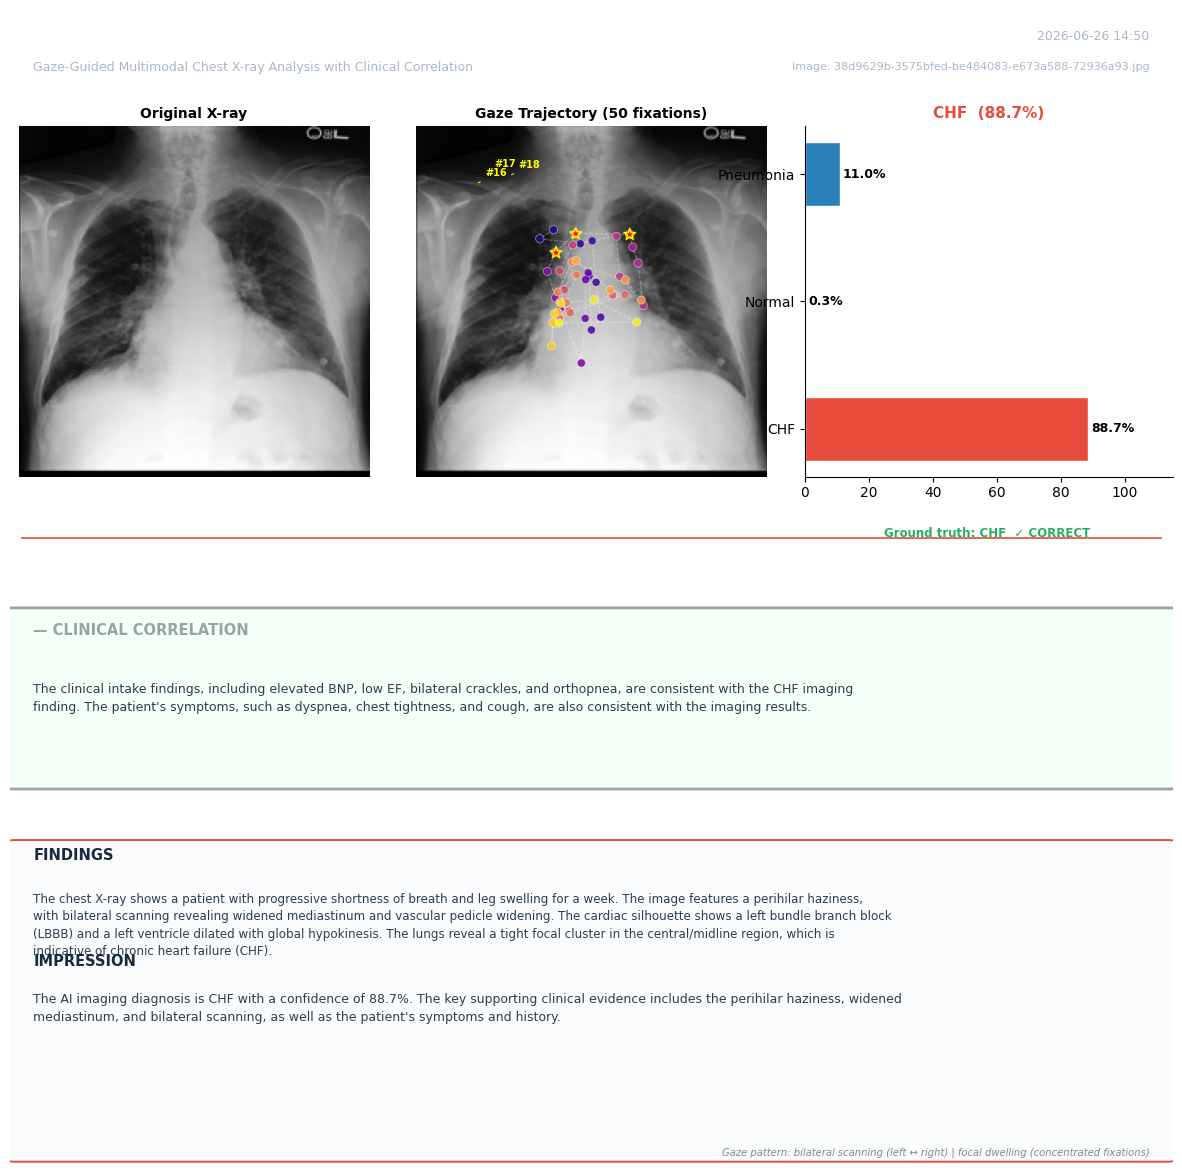

Report image saved: /kaggle/working/report_38d9629b-357.png

Grounding check: ✅ PASSED
Terminology coverage: 19% (3 terms used: ['perihilar haziness', 'widened mediastinum', 'vascular pedicle widening'])

Coordinate validity check: ✅ ALL VALID
Total coordinate citations in report: 0


In [38]:
def run_full_report(image_index=80, clinical_intake=None):
    """Entry point for Notebook 2 — uses pre-computed results, no model."""
    dicom_id   = list(test_results.keys())[image_index]
    img_path   = test_results[dicom_id]["image_path"]
    true_label = test_results[dicom_id]["true_label"]

    print(f"Processing: {os.path.basename(img_path)}  |  True: {LABEL_NAMES[true_label]}")

    result = generate_full_report(img_path, csv_index, df_full,
                                  clinical_intake=clinical_intake)
    if "error" in result:
        print(f"⚠️  {result['error']}")
        return None

    render_report(result, true_label=true_label)

    if "grounding_check"  in result: print_grounding_check(result["grounding_check"])
    if "coordinate_check" in result: print_coordinate_check(result["coordinate_check"])
    return result


# ── also define build_compact_fixation_description if not already present ─────
def build_compact_fixation_description(fix, weights, geometry, img_size=224):
    N = len(fix)
    norm_scores = weights / (weights.sum() + 1e-8)
    top_k_idx   = np.argsort(norm_scores)[::-1]
    lines = []
    lines.append(f"COORDINATE SYSTEM: {img_size}×{img_size} px. x=0 LEFT, x={img_size} RIGHT, y=0 TOP, y={img_size} BOTTOM.")
    lines.append(f"Heart: x={round(img_size*0.30)}-{round(img_size*0.62)}, y={round(img_size*0.45)}-{round(img_size*0.78)}")
    lines.append(f"Trachea: x={round(img_size*0.40)}-{round(img_size*0.60)}, y=0-{round(img_size*0.45)}")
    lines.append(f"Left lung: x<{round(img_size*0.45)}, Right lung: x>{round(img_size*0.55)}, Costophrenic: y>{round(img_size*0.75)}")
    lines.append(f"\nTOP 10 MOST INFLUENTIAL FIXATIONS (of {N} total):")
    for rank, idx in enumerate(top_k_idx[:10]):
        x_n, y_n = fix[idx, 0], fix[idx, 1]
        px, py   = round(float(x_n)*img_size), round(float(y_n)*img_size)
        h = "left" if x_n < 0.38 else ("right" if x_n > 0.62 else "center")
        v = "upper" if y_n < 0.38 else ("lower" if y_n > 0.62 else "mid")
        lines.append(f"  [{rank+1:02d}] pixel({px:3d},{py:3d}) | imp={norm_scores[idx]:.3f} | {v}-{h}")
    g_all = geometry["all"]
    lines.append(f"\nFULL TRAJECTORY: centroid={g_all['pixel_centroid']}, bbox={g_all['pixel_bbox']}, {g_all['spread_desc']}, {g_all['horizontal_desc']}, {g_all['vertical_desc']}")
    if geometry.get("top_k"):
        g = geometry["top_k"]
        lines.append(f"HIGH-ATTENTION CLUSTER: centroid={g['pixel_centroid']}, {g['spread_desc']}, {g['horizontal_desc']}, {g['vertical_desc']}")
    return "\n".join(lines)

# ── Example: full clinical intake matching a pneumonia presentation ──────────
chf_intake = {
    "symptoms": {
        "chief_complaint": "progressive shortness of breath and leg swelling for 1 week",
        "dyspnea_severity": "severe, present at rest (orthopnea requiring 3 pillows)",
        "chest_pain": "none, but reports chest tightness when supine",
        "cough": "frequent nocturnal cough, productive of frothy pink-tinged sputum",
        "fever": False,
    },
    "physical_exam": {
        "bp": "154/92", 
        "hr": 104, 
        "spo2": "89% on room air", 
        "temp": "36.7C",
        "auscultation": "bilateral basilar crackles (rales) extending into mid-lung fields and an S3 gallop",
        "edema": "3+ pitting bilateral lower extremity edema to the knees",
    },
    "history": {
        "cardiac": "ischemic cardiomyopathy, prior MI in 2021, chronic HFrEF",
        "pulmonary": "none",
        "other": "essential hypertension, type 2 diabetes",
    },
    "prior_diagnostics": {
        "ecg": "sinus tachycardia, left bundle branch block (LBBB)",
        "echo": "prior echo reveals LVEF of 32% with global hypokinesis and dilated left ventricle",
        "labs": "NT-proBNP 4,250 pg/mL (severely elevated), serum creatinine 1.4 (mildly elevated)",
    },
    "positioning": {
        "view": "AP", 
        "patient_position": "semi-fowler / portable supine (due to acute distress)"
    },
    "technical_quality": {
        "inspiration": "poor due to dyspnea", 
        "rotation": "mild rotation to the right", 
        "penetration": "adequate"
    },
}

result = run_full_report(image_index=5, clinical_intake=chf_intake)

Displaying: /kaggle/working/report_38d9629b-357.png


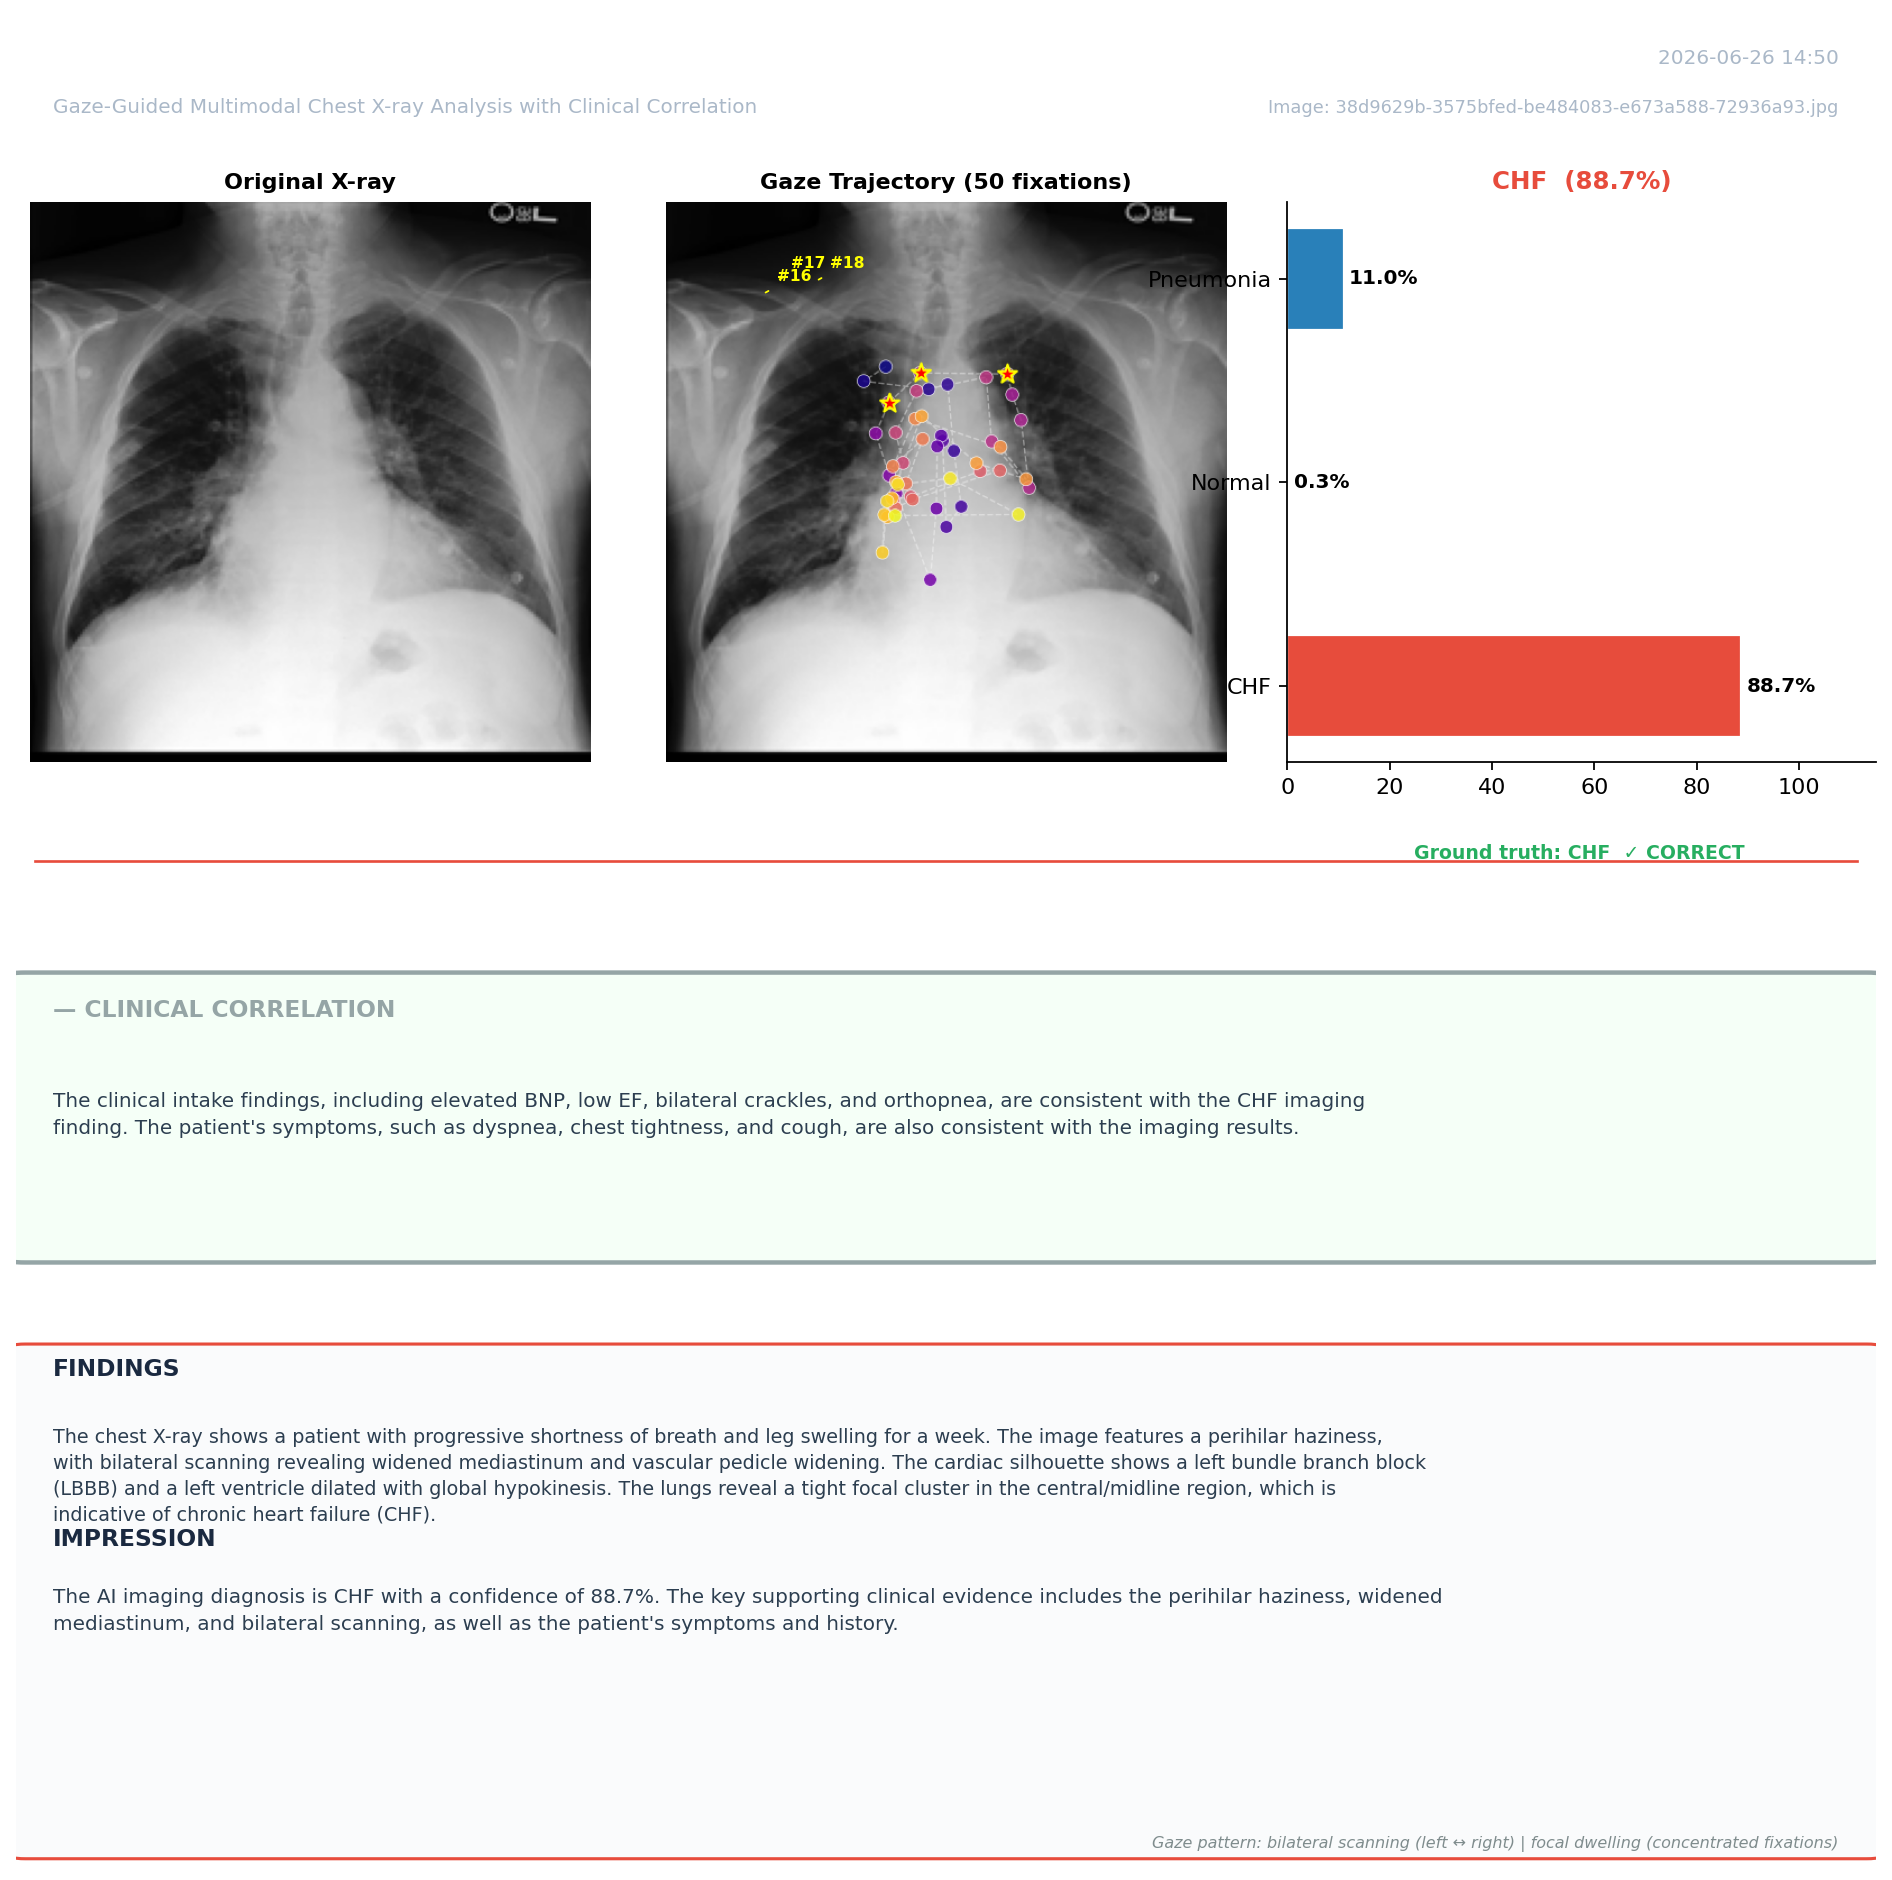

In [39]:
# Force-display the generated PNG file directly in the notebook
from IPython.display import Image, display
import os

# Get the last generated report from your working directory
working_dir = "/kaggle/working"
reports = [f for f in os.listdir(working_dir) if f.startswith("report_") and f.endswith(".png")]

if reports:
    latest_report = os.path.join(working_dir, sorted(reports)[-1])
    print(f"Displaying: {latest_report}")
    display(Image(filename=latest_report))
else:
    print("No report image found in /kaggle/working yet. Make sure to run your execution cell first!")